# 🚢 Titanic dataset EDA 🔍

###     [СССЫЛКА НА ДАТАСЕТ](https://www.kaggle.com/competitions/titanic/data)

Классический ML-датасет для предсказания выживаемости(survived = 0/1) пассажиров на Титанике

| Колонка   | Описание                                             | Тип               |
|-----------|------------------------------------------------------|-------------------|
| Survived  | Целевая переменная (0 = погиб, 1 = выжил)            | Бинарный          |
| Pclass    | Класс билета (1, 2, 3)                               | Порядковый        |
| Name      | Имя пассажира                                        | Текст             |
| Sex       | Пол (male/female)                                    | Категориальный    |
| Age       | Возраст                                              | Числовой          |
| SibSp     | Кол-во братьев/супругов на борту                     | Числовой          |
| Parch     | Кол-во родителей/детей на борту                      | Числовой          |
| Ticket    | Номер билета                                         | Текст             |
| Fare      | Цена билета                                          | Числовой          |
| Cabin     | Номер каюты                                          | Категориальный    |
| Embarked  | Порт посадки (C, Q, S)                               | Категориальный    |

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

### Загрузка данных

In [2]:
df = pd.read_csv('train.csv')

## Быстрый обзор данных(pandas) 🐼🐼🐼

In [3]:
for item in df.columns: # Названия столбцов
    print(item)

count = df.columns.size
print(f"\nCount: {count}")

PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked

Count: 12


In [4]:
df.head() # вывод первых строк(5 по умолчанию)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail() # вывод последних строк(5 по умолчанию)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.shape # размерность датасета

(891, 12)

In [7]:
df.info() # Краткая сводка о датасете(Названия столбцов, количество непустых значений в столбцах, типы данных столбцов)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.describe().round() # Статистическое описание

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0,891.0,891.0,714.0,891.0,891.0,891.0
mean,446.0,0.0,2.0,30.0,1.0,0.0,32.0
std,257.0,0.0,1.0,15.0,1.0,1.0,50.0
min,1.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,224.0,0.0,2.0,20.0,0.0,0.0,8.0
50%,446.0,0.0,3.0,28.0,0.0,0.0,14.0
75%,668.0,1.0,3.0,38.0,1.0,0.0,31.0
max,891.0,1.0,3.0,80.0,8.0,6.0,512.0


In [9]:
df.describe(include='str')

# Что видим:
# count  - количество непустых значений
# unique - количество уникальных значений
# top    - самое частое значение (мода)
# freq   - частота самого частого значения

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [10]:
df.duplicated().sum() # Проверка на полные дубликаты строк

np.int64(0)

Дубликатов нет

## 🧩 Обработка пропусков

In [11]:
df.isnull().sum() # Количество пропусков по столбцам

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Что мы видим: В Cabin много пропусков(687), а в Emarked всего 2(<1%), сразу напрашивается желание просто выкинуть из датасета двух пассажиров без Embarked, т.к. таких пассажиров очень мало, но мы заполним их модой, чтобы по минимуму терять данные. а столбец Cabin удалить, так как опасно заполнять такое огромное количество пропусков "искуственными" данными

In [12]:
# df = df.dropna(subset='Embarked') # Удалим строки, где Embarked отсутствует МОЖНО ТАК

df = df.dropna(axis=1, thresh=len(df) * 0.5) # удалим столбцы, где >50% пропусков(axis - флаг, отвечающий за удаление строк или столбцов, thresh - по сути порог, если он превышен - удаление)

In [13]:
# Подсчёт моды для категориального признака Embarked(порт высадки)



mode_embarked = df['Embarked'].mode()[0]

print(mode_embarked)

S


In [14]:
# Заполним пропуски модой

df['Embarked'] = df['Embarked'].fillna(mode_embarked)

С признаком Age несколько интереснее, 

In [15]:
df.isnull().sum() # Проверка пропусков после удаления

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [16]:
# Построим boxplot для выбора дальнейшей стратегии заполнения пустых Age
fig2 = px.box(df, y='Age')


fig2.show()


По графику видно, что есть возраста выше upperfence = 65, но это **НЕ ВЫБРОСЫ**, тут нет никакой аномалии, это естественно для возраста людей, на борту находились пожилые люди.


### Гипотезы для дальнейшего исследования
Возраст может коррелировать с другими признаками:
- **Класс билета (pclass)** — возможно, в 1-м классе пассажиры старше
- **Цена билета (fare)** — дорогие билеты могли покупать взрослые/пожилые
- **Пол (sex)** — возможно, разный возраст у мужчин и женщин

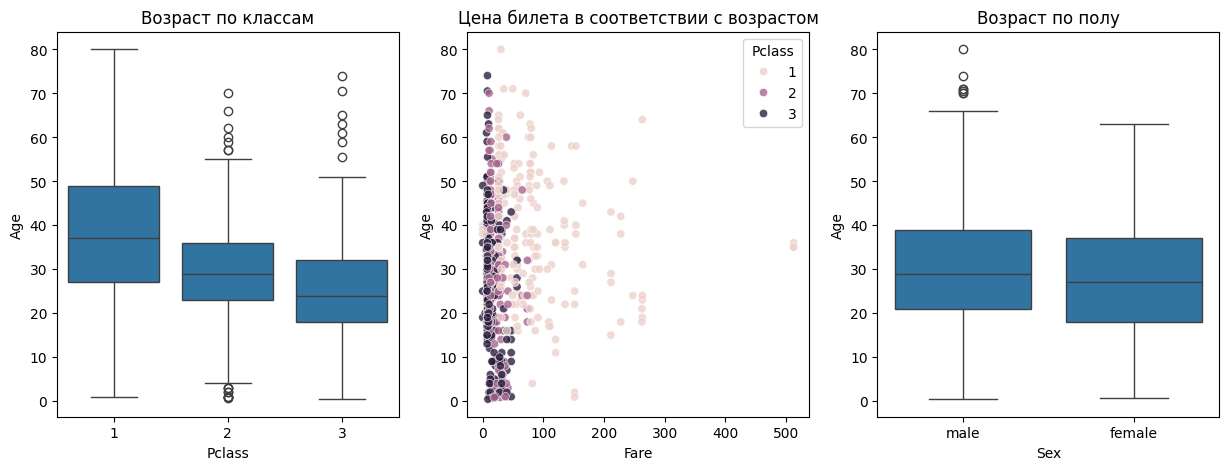

In [17]:
plt.figure(figsize=(15, 5))

# Гипотеза 1: зависимость от класса
plt.subplot(1, 3, 1)
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Возраст по классам')

# Гипотеза 2: зависимость от цены
plt.subplot(1, 3, 2)
sns.scatterplot(x='Fare', y='Age', hue='Pclass', data=df, alpha=0.8)
plt.title('Цена билета в соответствии с возрастом')

# Гипотеза 3: зависимость от пола
plt.subplot(1, 3, 3)
sns.boxplot(x='Sex', y='Age', data=df)
plt.title('Возраст по полу')

plt.show()

**Что мы видим:** в 1 классе явно больше взрослых/стариков, а в промежутке от 20 до 60 лет больше всего дорогих билетов(>100). А от пола возраст не зависит, что вполне ожидаемо.
более явная статистика указана в первом случае(возраст коррелирует с классом билета)  

**Дальнешая стратегия заполнения:** Итак, на основание нашей проверки гипотезы **будем заполнять пропуски в Age медианой по классу билетов**, так как **глобальная медиана не подойдёт**, потому что она будет игнорировать, что в 1 классе люди зачастую старше, так же отмечу, что **заполнение средним не подойдет** так как есть пожилые люди, и среднее чувствительно к их значениями. **Заполнение модой бессмысленно**, т.к. много уникальных значений в возрасте.

In [18]:
# Считаем медианы по классам
medians = df.groupby('Pclass')['Age'].median()

for pclass, median in medians.items():
    print(f"  Класс {pclass}: {median:.1f} лет")

  Класс 1: 37.0 лет
  Класс 2: 29.0 лет
  Класс 3: 24.0 лет


In [19]:
# Заполняем медианой пропуски в Age в соответствии с классом билета

for pclass, median in medians.items():
    mask = (df['Pclass'] == pclass) # булева маска

    df.loc[mask, 'Age'] = df.loc[mask, 'Age'].fillna(median) # выбираем возраст из конкретного класса билета и заполняем медианой



In [20]:
df.isnull().sum() # Проверим сейчас количество пропусков

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Готово, теперь пропусков в данных нет

# Расширенная статистика

### Базовые метрики: min, max, mean, median, mode

In [21]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

stats_df = pd.DataFrame(index=numeric_cols)

for col in numeric_cols:
    stats_df.loc[col, 'min'] = df[col].min()
    stats_df.loc[col, 'max'] = df[col].max()
    stats_df.loc[col, 'mean'] = df[col].mean()
    stats_df.loc[col, 'median'] = df[col].median()

    # mode может быть несколько, берём первую
    mode_val = df[col].mode()
    stats_df.loc[col, 'mode'] = mode_val[0]

print(stats_df.round(2))
    

        min     max   mean  median   mode
Age    0.42   80.00  29.07   26.00  24.00
Fare   0.00  512.33  32.20   14.45   8.05
SibSp  0.00    8.00   0.52    0.00   0.00
Parch  0.00    6.00   0.38    0.00   0.00


### Процентили (квантили)

In [22]:
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95] # Процентили, которые считаем

percentile_df = pd.DataFrame(index=numeric_cols)

for col in numeric_cols:
    for p in percentiles:
        percentile_df.loc[col, f'{int(p*100)}%'] = df[col].quantile(p)

print(percentile_df.round(2))

         5%    25%    50%   75%     95%
Age    6.00  22.00  26.00  37.0   54.00
Fare   7.22   7.91  14.45  31.0  112.08
SibSp  0.00   0.00   0.00   1.0    3.00
Parch  0.00   0.00   0.00   0.0    2.00


### Дисперсия (Variance)

In [23]:
for col in numeric_cols:
    variance = df[col].var()
    print(f"  {col}: {variance:.2f}")

  Age: 175.42
  Fare: 2469.44
  SibSp: 1.22
  Parch: 0.65


Дисперсия - мера, насколько данные разбросаны. В датасете титаника Fare имеет наибольшую дисперсию, т.к. цены билетов сильно варьируются от дешевых до дорогих. у Age так же большая дисперсия, на борту много возрастов. А у SibSp и Parch малая дисперсия, что, впринципе, логично, так как ни у одного из этих признаков значение в большинстве случаев не превосходит 4-5.(Посмотрел через плагин data wrangler)

Text(0.5, 1.0, 'Распределение цены билета')

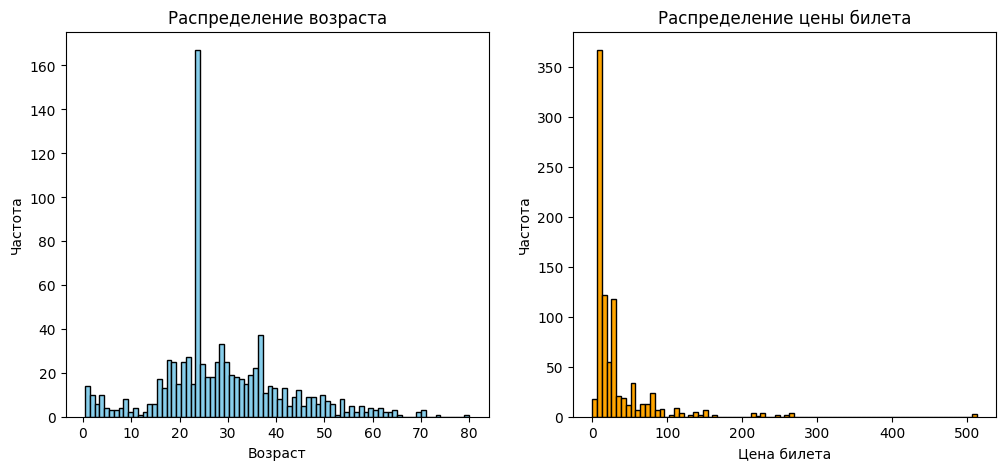

In [24]:
plt.figure(figsize=(12, 5))

# Первый график (Age)
plt.subplot(1, 2, 1)  # 1 строка, 2 колонки, первый график
plt.hist(df['Age'], bins=80, edgecolor='black', color='skyblue')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста')

# Второй график (Fare)
plt.subplot(1, 2, 2)  # 1 строка, 2 колонки, второй график
plt.hist(df['Fare'], bins=80, edgecolor='black', color='orange')
plt.xlabel('Цена билета')
plt.ylabel('Частота')
plt.title('Распределение цены билета')

огромная дисперсия подтверждается на графиках(видно "взлёты" и разрозненность данных, нет общего центра) 

### Асимметрия (Skewness)

In [25]:
for col in numeric_cols:
    skew = df[col].skew()
    print(f"  {col}: {skew:.2f}")

  Age: 0.55
  Fare: 4.79
  SibSp: 3.70
  Parch: 2.75


Что такое асимметрия:

    0 — симметричное распределение (нормальное)

    >0 — правосторонняя асимметрия (хвост справа, много маленьких значений)

    <0 — левосторонняя асимметрия (хвост слева, много больших значений)

Для Титаника:

    Fare → сильная положительная асимметрия (много дешёвых билетов, несколько очень дорогих)

    Age → умеренная положительная асимметрия (больше молодых, хвост из пожилых)

    SibSp/Parch → сильная асимметрия (большинство без семьи)

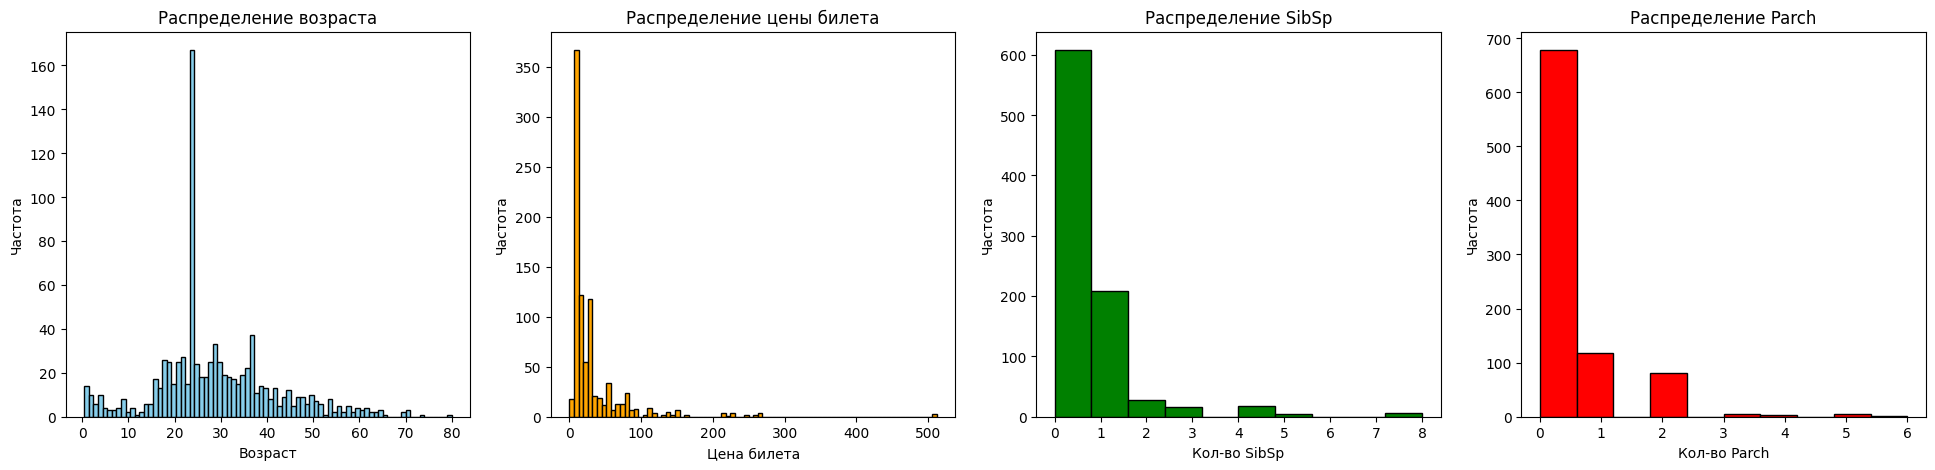

In [26]:
plt.figure(figsize=(24, 5))

# Первый график (Age)
plt.subplot(1, 4, 1)  
plt.hist(df['Age'], bins=80, edgecolor='black', color='skyblue')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста')

# Второй график (Fare)
plt.subplot(1, 4, 2)  
plt.hist(df['Fare'], bins=80, edgecolor='black', color='orange')
plt.xlabel('Цена билета')
plt.ylabel('Частота')
plt.title('Распределение цены билета')

# Третий график (SibSp)
plt.subplot(1, 4, 3) 
plt.hist(df['SibSp'], bins=10, edgecolor='black', color='green')
plt.xlabel('Кол-во SibSp')
plt.ylabel('Частота')
plt.title('Распределение SibSp')

# Четвертый график (Parch)
plt.subplot(1, 4, 4) 
plt.hist(df['Parch'].dropna(), bins=10, edgecolor='black', color='red')
plt.xlabel('Кол-во Parch')
plt.ylabel('Частота')
plt.title('Распределение Parch')

plt.show()


Во всех графиках виден "Хвост" из данных справа, соответственно, логично, что у всех этих признаков Асимметрия положительная(правосторонняя)

### Эксцесс (Kurtosis)

Эксцесс, это то, как расположены данные в распределении, а именно:

    0 — как у нормального распределения

    >0 — острый пик (данные сконцентрированы в центре)

    <0 — плоский пик (данные распределены равномерно)

In [27]:
for col in numeric_cols:
    kurt = df[col].kurtosis()  
    print(f"  {col}: {kurt:.2f}")

  Age: 0.78
  Fare: 33.40
  SibSp: 17.88
  Parch: 9.78


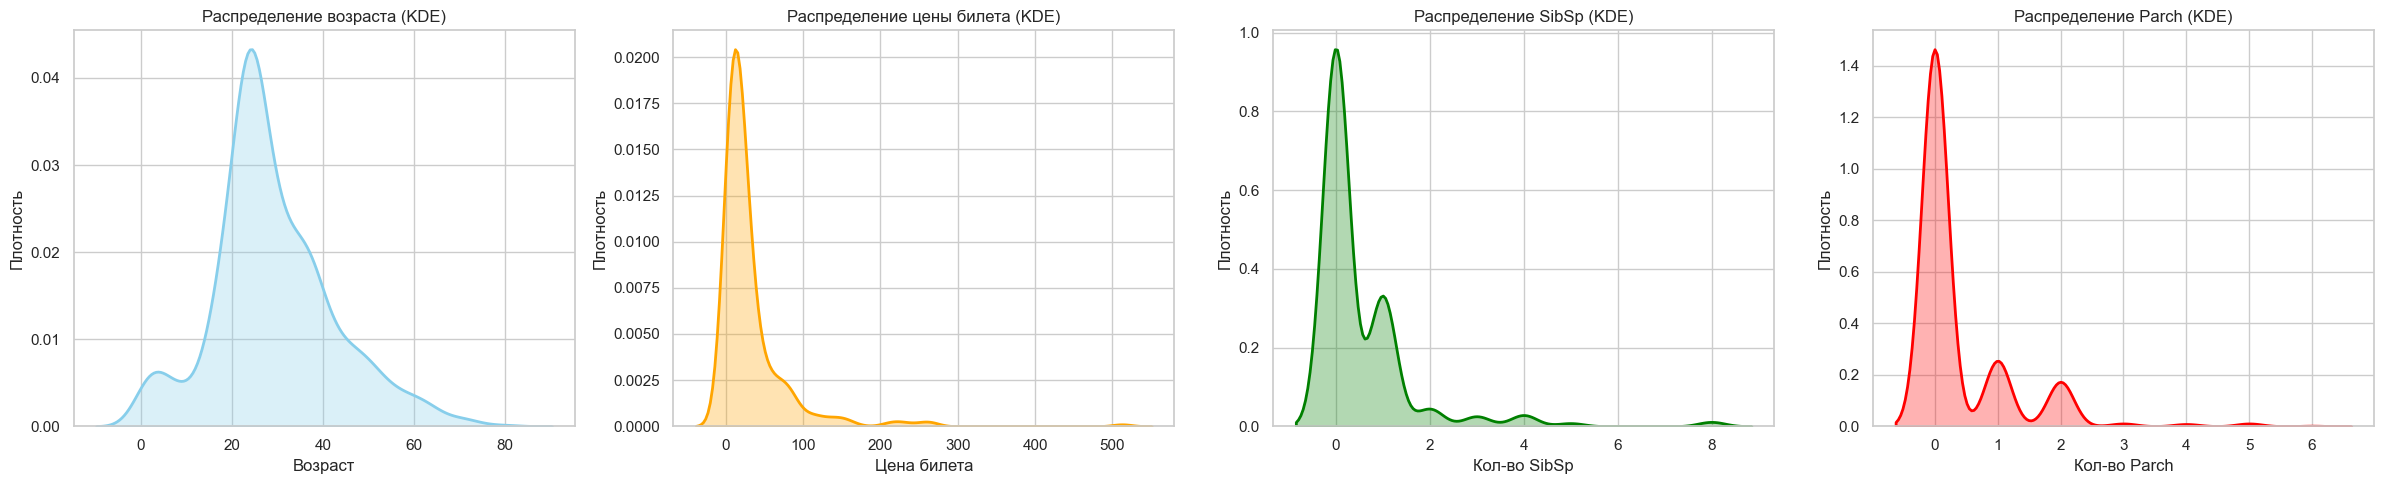

In [42]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(24, 5))

# Первый график (Age)
plt.subplot(1, 4, 1)
sns.kdeplot(data=df, x='Age', color='skyblue', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Возраст')
plt.ylabel('Плотность')
plt.title('Распределение возраста (KDE)')

# Второй график (Fare)
plt.subplot(1, 4, 2)
sns.kdeplot(data=df, x='Fare', color='orange', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Цена билета')
plt.ylabel('Плотность')
plt.title('Распределение цены билета (KDE)')

# Третий график (SibSp)
plt.subplot(1, 4, 3)
sns.kdeplot(data=df, x='SibSp', color='green', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Кол-во SibSp')
plt.ylabel('Плотность')
plt.title('Распределение SibSp (KDE)')

# Четвертый график (Parch)
plt.subplot(1, 4, 4)
sns.kdeplot(data=df, x='Parch', color='red', fill=True, alpha=0.3, linewidth=2)
plt.xlabel('Кол-во Parch')
plt.ylabel('Плотность')
plt.title('Распределение Parch (KDE)')

plt.tight_layout()
plt.show()

На графиках видно, что только признак Age близок к нормальному распределению, что и подтверждает числовое значение эксцесса Age, оно близко к нулю.

Для Титаника:

    Fare → большой положительный эксцесс (очень много дешёвых билетов, резкий пик)

    SibSp → большой положительный эксцесс (большинство 0, резко меньше 1,2...)

    Age → эксцесс около 0 (близко к нормальному)

## Фичи: Энкодинг и Инжиниринг (Feature Engineering)

### OneHotEncoder / pd.get_dummies

In [31]:
df_encoded_onehot = pd.get_dummies(df, columns=['Sex', 'Embarked'], prefix=['Sex', 'Emb'])

df_encoded_onehot.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Emb_C,Emb_Q,Emb_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,False,True


### Target Encoding (среднее по таргету)

In [32]:
target_mean_sex = df.groupby('Sex')['Survived'].mean()
target_mean_emb = df.groupby('Embarked')['Survived'].mean()

print("Target encoding для Sex:")
print(target_mean_sex)
print("\nTarget encoding для Embarked:")
print(target_mean_emb)  

df_encoded_target = df.copy()
df_encoded_target['Sex_Target'] = df_encoded_target['Sex'].map(target_mean_sex)
df_encoded_target['Emb_Target'] = df_encoded_target['Embarked'].map(target_mean_emb)

print(df_encoded_target[['Sex', 'Sex_Target', 'Embarked', 'Emb_Target']].head(10))


Target encoding для Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Target encoding для Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64
      Sex  Sex_Target Embarked  Emb_Target
0    male    0.188908        S    0.339009
1  female    0.742038        C    0.553571
2  female    0.742038        S    0.339009
3  female    0.742038        S    0.339009
4    male    0.188908        S    0.339009
5    male    0.188908        Q    0.389610
6    male    0.188908        S    0.339009
7    male    0.188908        S    0.339009
8  female    0.742038        S    0.339009
9  female    0.742038        C    0.553571


### Feature Hashing

Хэширование уместо применять в тех столбцах, где много уникальных значений, в данном датасете это будет Name и Ticket

In [37]:
from sklearn.feature_extraction import FeatureHasher

df_hash = df.copy()

# Feature Hashing для Ticket
hashing_ticket = FeatureHasher(n_features=10, input_type='string')
ticket_features = hashing_ticket.fit_transform(df_hash[['Ticket']].astype(str).values)

ticket_df = pd.DataFrame(
    ticket_features.toarray(),
    columns=[f'Ticket_Hash_{i}' for i in range(10)],
    index=df_hash.index
)

ticket_df.head()

,Ticket_Hash_0,Ticket_Hash_1,Ticket_Hash_2,Ticket_Hash_3,Ticket_Hash_4,Ticket_Hash_5,Ticket_Hash_6,Ticket_Hash_7,Ticket_Hash_8,Ticket_Hash_9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# Feature Hashing для Name
hashing_name = FeatureHasher(n_features=15, input_type='string')
name_features = hashing_name.fit_transform(df_hash[['Name']].astype(str).values)

name_df = pd.DataFrame(
    name_features.toarray(),
    columns=[f'Name_Hash_{i}' for i in range(15)],
    index=df_hash.index
)

name_df.head()

,Name_Hash_0,Name_Hash_1,Name_Hash_2,Name_Hash_3,Name_Hash_4,Name_Hash_5,Name_Hash_6,Name_Hash_7,Name_Hash_8,Name_Hash_9,Name_Hash_10,Name_Hash_11,Name_Hash_12,Name_Hash_13,Name_Hash_14
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Генерация новых фич (Feature Creation)

можно создать признак Размер семьи

In [39]:
df_feat = df.copy()

# Суммируем супругов и детей (+1 за самого пассажира)
df_feat['FamilySize'] = df_feat['SibSp'] + df_feat['Parch'] + 1

# Категоризуем размер семьи
def family_type(size):
    if size == 1:
        return 'Alone'
    elif size <= 3:
        return 'Small'
    elif size <= 5:
        return 'Medium'
    else:
        return 'Large'

df_feat['FamilyType'] = df_feat['FamilySize'].apply(family_type)

df_feat[['SibSp', 'Parch', 'FamilySize', 'FamilyType']].head(10)

,SibSp,Parch,FamilySize,FamilyType
0,1,0,2,Small
1,1,0,2,Small
2,0,0,1,Alone
3,1,0,2,Small
4,0,0,1,Alone
5,0,0,1,Alone
6,0,0,1,Alone
7,3,1,5,Medium
8,0,2,3,Small
9,1,0,2,Small


можно создать признак Возрастная группа

In [41]:
def age_group(age):
    if age < 12:
        return 'Child'
    elif age < 18:
        return 'Teen'
    elif age < 35:
        return 'Young_Adult'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df_feat['AgeGroup'] = df_feat['Age'].apply(age_group)


df_feat['AgeGroup'].value_counts()

AgeGroup
Young_Adult    513
Adult          239
Child           68
Teen            45
Senior          26
Name: count, dtype: int64

#  Визуализация (Самая красивая часть!) 🎨

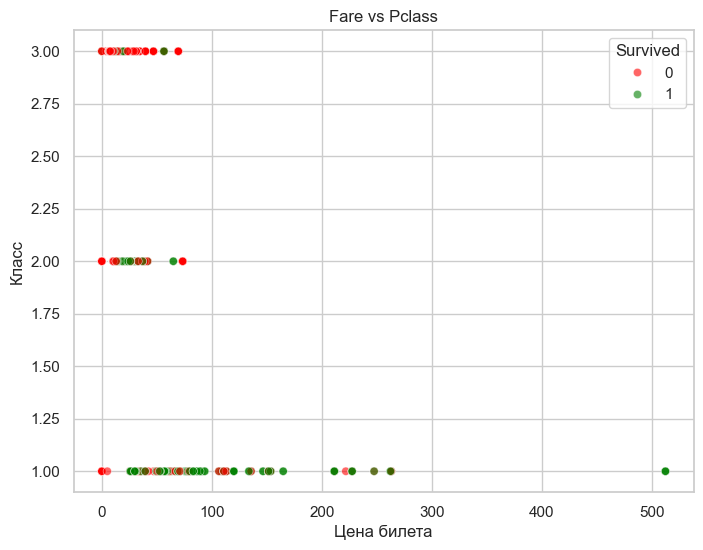

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, 
                x='Fare', 
                y='Pclass', 
                hue='Survived', 
                palette={0: 'red', 1: 'green'},  # 0=погиб(красный), 1=выжил(зеленый)
                alpha=0.6)

plt.title('Fare vs Pclass')
plt.xlabel('Цена билета')
plt.ylabel('Класс')

plt.show()

На этом графике видно, что люди больше выживали в первом классе, а так же, почти все у кого цена билета >100 выжили. И почти не выживали люди в третьем классе.

## Heatmap корреляций

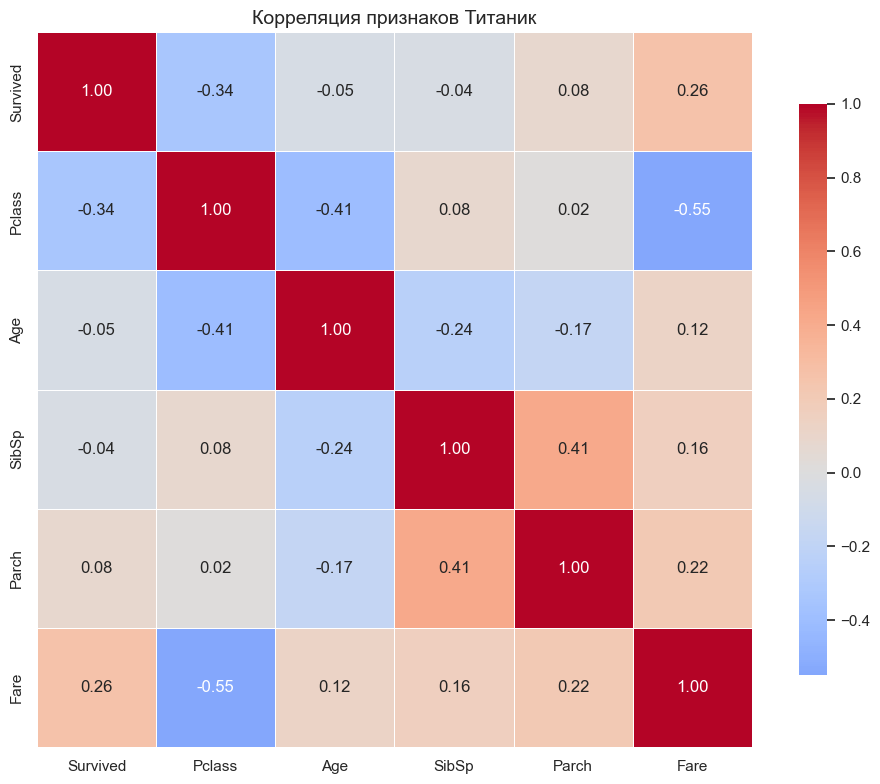

In [51]:
# Выбираем числовые колонки
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,           # показать цифры
            cmap='coolwarm',      # цветовая схема
            center=0,             # центр цветовой шкалы
            square=True,          # квадратные ячейки
            linewidths=0.5,       # линии между ячейками
            fmt='.2f',            # формат чисел
            cbar_kws={'shrink': 0.8})

plt.title('Корреляция признаков Титаник', fontsize=14)
plt.tight_layout()
plt.show()

Сильные корреляции (|корр| > 0.5):
- Pclass и Fare: -0.55  (чем выше класс, тем дороже билет — логично)

Средние корреляции (0.3 < |корр| < 0.5):
- Pclass и Survived: -0.34  (чем выше класс, тем выше выживаемость)
- Fare и Survived: 0.26     (дорогие билеты = выше выживаемость)
- SibSp и Parch: 0.41       (супруги и дети часто едут вместе)

Слабые корреляции (< 0.2):
- Age с остальными признаками(кроме Pclass)
- SibSp/Parch с Survived

# **<center>ПОСЛЕСЛОВИЕ</center>**

Что я понял про датасет:
- Класс обслуживания (Pclass) сильно влияет на выживаемость — в 1-м классе выжили ~63%, во 2-м ~47%, в 3-м только ~24%
- Пол — важнейший фактор выживания — 74% женщин выжили против всего 19% мужчин (правило "женщины и дети первыми", видел такое в документальном фильме)
- Возраст имеет естественный разброс от 0 до 80 лет — значения выше upper fence (65+) это не выбросы, а пожилые пассажиры, которые реально были на борту
- Цена билета (Fare) имеет огромный правый хвост — есть несколько очень дорогих билетов (до 512), но основная масса пассажиров ехала в 3-м классе с дешёвыми билетами
- SibSp и Parch коррелируют — супруги и дети часто едут вместе (корр = 0.41)
- Корреляция Pclass и Fare ожидаема — чем выше класс, тем дороже билет (корр = -0.55)

Гипотезы и наблюдения:
- Женщины выживали чаще не просто потому что они женщины, а потому что их сажали в шлюпки в первую очередь — это социальный/поведенческий фактор
- Дорогие билеты = выше выживаемость — возможно, потому что каюты 1-го класса были ближе к шлюпкам, либо пассажиров 1-го класса спасали в первую очередь
- Дети выживали чаще взрослых — даже в 3-м классе дети имели приоритет при эвакуации


Какую модель бы взял? Линейную. Так как других моделей особо не знаю и хочу начать с основ.

Подсказки AI:

    Как построить subplot с несколькими графиками

    Синтаксис groupby для групповых статистик

    Разница между медианой и средним для заполнения пропусков

    Как в seaborn менять цвета в scatterplot (palette={0:'red', 1:'green'})

    Что такое Feature Hashing и как применить к Ticket/Name

    Как читать boxplot и что значит upper fence
    
    Почти вся теория по статистике, т.к. ещё не изучал её

    Почти вся работа с библиотеками pandas

    Почти вся визуализация

    Какие новые признаки можно создать


На основе промтов типа "Не пиши за меня код, а дай подобие документации" писал остальное сам.